### Value at risk

* Mesurement of downside risk based on current value at portfolio or security and expected volatility - expected return is optional
* In addition a time horizon is needed and a confidence level
* VaR allows you to make statements like at 99% confidence level losses will not exceed $-- in the text - days/weeks/months/years
* Of course there are problems with VaR - the biggest beign how big the loss can grow to if volatility moves past the confidence level

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yfi
from scipy.stats import norm
%matplotlib inline

In [5]:
confidence_level = .99
trading_days = 252
portfolio_val = 760000
volatility = .307
trading_days_month = 21
cut_off = norm.ppf(confidence_level)
var = portfolio_val * volatility * np.sqrt(trading_days_month/trading_days) * cut_off
print("At {:.2f} confidence level, loss will not exceed {:,.2f}$".format(confidence_level, var))
print("This represents a move of {:.2f} standard desviations below the expected..".format(volatility))

At 0.99 confidence level, loss will not exceed 156,688.10$
This represents a move of 0.31 standard desviations below the expected..


Valor total de la posición: $1,244,800.03
[-40561.81573397 -22528.42001454  15665.90875249 ... -10533.62479608
  12849.34957809  33462.54606722]  este es el resultado
Percentil 1% o 99% de confianza -53053.170460679554


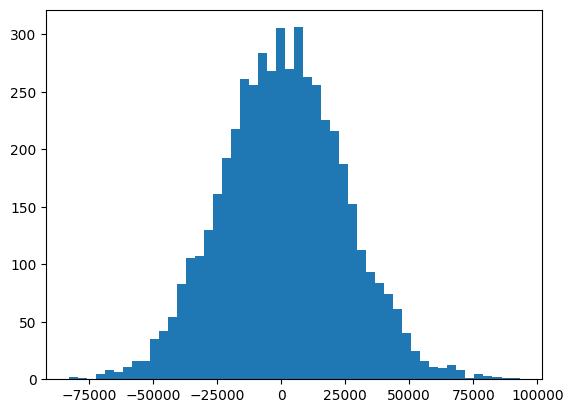

In [51]:
apple_shares = 5000
# Bajamos un poco más de historial para asegurar que tenemos datos
gld_data = yfi.download("AAPL", start="2026-03-01", progress=False)
apple_price = float(gld_data['Close'].iloc[-1].iloc[0])
pv = apple_shares * apple_price
print(f"Valor total de la posición: ${pv:,.2f}")
volatility = .307    
iterations = 5000
T = 1/252            
er = 0.05            

def calcular_montecarlo_var(pv, er, vol, T, iterations):
    # Fórmula de GBM corregida: todo dentro del np.exp
    # S_t = S_0 * exp((mu - 0.5 * sigma^2) * T + sigma * sqrt(T) * Z)
    random_noise = np.random.standard_normal(iterations)
    end_prices = pv * np.exp((er - 0.5 * vol**2) * T + vol * np.sqrt(T) * random_noise)
    
    # Calculamos pérdidas y ganancias (P&L)
    pnl = end_prices - pv
    return pnl
resultados_pnl = calcular_montecarlo_var(pv, er, volatility, T, iterations)
print(resultados_pnl," este es el resultado")
plt.hist(calcular_montecarlo_var(pv, er, volatility, T, iterations), bins=50)

var = np.percentile(resultados_pnl, 1)
print("Percentil 1% o 99% de confianza", var)